In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles
 
 


In [2]:
# ---------------------------------------------------------------------------
# PART 1: Tiny hand-made example -- see core/border/noise directly
# ---------------------------------------------------------------------------

# NP.ARRAY TAKES LIST AND COIVERT IN ARRAY
X_small = np.array([
    [1, 2],
    [2, 2],
    [2, 3],
    [8, 7],
    [8, 8],
    [25, 80],   # a lone far-away point -- expected to be noise
])
 


In [3]:
dbscan_small = DBSCAN(eps=3, min_samples=2)
dbscan_small.fit(X_small)
#  .fit() pattern you've seen many times — this is where DBSCAN actually does its work: 
# it goes through every point in X_small, checks how many neighbors each one has within eps=3, 
# and classifies each point as core, border, or noise, then groups the core/border points into 
# clusters.


,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",2
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[int64](5, 2)","[[1,2], [2,2], [2,3], [8,7], [8,8]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](5,)","[0,1,2,3,4]"


In [4]:

print("Small example labels:", dbscan_small.labels_)
# Read this as: which cluster number each point in X_small belongs to,
# in the same order as X_small. -1 means noise.
#  Important nuance worth noticing: unlike LogisticRegression.fit(X_train, y_train), 
# notice dbscan_small.fit(X_small) only takes one argument, not two. There's no y 
# (labels) being passed in at all. This is the direct, concrete proof of something we
#  mentioned earlier: DBSCAN is unsupervised — there are no "correct answers" to learn from.
#  It's not being told which cluster each point should belong to; it's figuring that out 
# entirely on its own, purely from how the points are spatially arranged.
 


Small example labels: [ 0  0  0  1  1 -1]


In [5]:
# ---------------------------------------------------------------------------
# PART 2: Concentric circles -- where DBSCAN actually shines
# ---------------------------------------------------------------------------
X_circles, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
 
dbscan_circles = DBSCAN(eps=0.15, min_samples=5)
cluster_labels = dbscan_circles.fit_predict(X_circles)
 


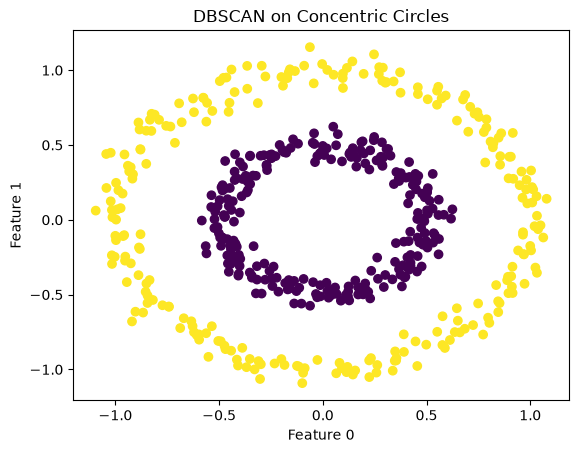

In [6]:
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=cluster_labels, cmap="viridis")
plt.title("DBSCAN on Concentric Circles")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()
 


In [7]:
print("Number of clusters found:", len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))
print("Number of noise points:", list(cluster_labels).count(-1))

Number of clusters found: 2
Number of noise points: 0
